In [170]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [172]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [174]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [175]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [176]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [177]:
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

rare_titles = ['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
               'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']

df['Title'] = df['Title'].replace(rare_titles, 'Rare')

df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',
    'Ms'  : 'Miss',
    'Mme' : 'Mrs'
})

title_mapping = {
    'Mr'    : 1,
    'Miss'  : 2,
    'Mrs'   : 3,
    'Master': 4,
    'Rare'  : 5
}

df['Title'] = df['Title'].map(title_mapping)

In [178]:
X = df.drop(['PassengerId', 'Survived'], axis=1)
y = df['Survived']

In [179]:
X

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,3
2,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,3
4,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...
886,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S,5
887,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,S,2
888,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,NaN,1,2,W./C. 6607,23.4500,NaN,S,2
889,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C,1


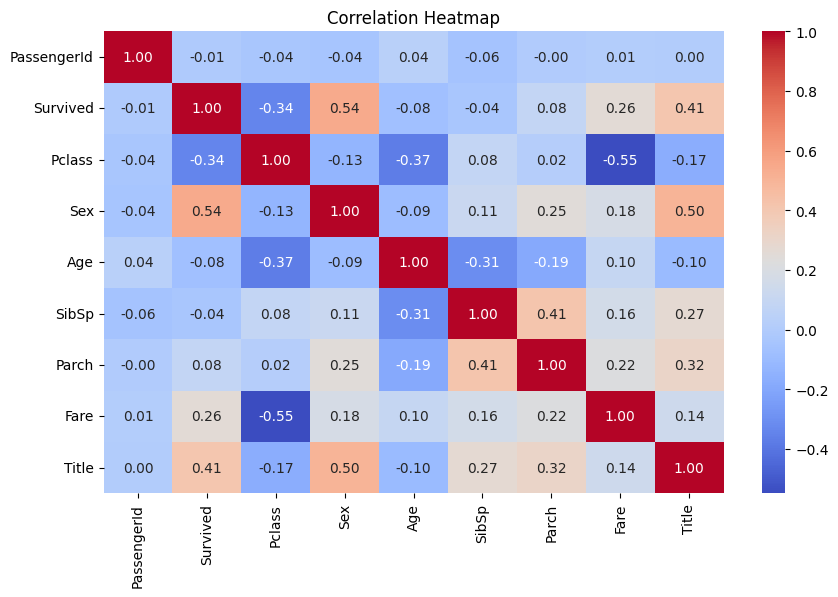

In [180]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [181]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,3
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,3
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",0,27.0,0,0,211536,13.0000,NaN,S,5
887,888,1,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,112053,30.0000,B42,S,2
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,NaN,1,2,W./C. 6607,23.4500,NaN,S,2
889,890,1,1,"Behr, Mr. Karl Howell",0,26.0,0,0,111369,30.0000,C148,C,1


In [182]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

712
179
712
179


In [183]:
X_train['Embarked'] = X_train['Embarked'].fillna(X_train['Embarked'].mode()[0])

In [184]:
X_train['Age'] = X_train.groupby(['Sex', 'Pclass'])['Age'].transform(lambda x: x.fillna(x.median()))

In [185]:
X_train.isna().sum()

Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       553
Embarked      0
Title         0
dtype: int64

In [186]:
X_train.drop('Name', axis=1)

,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
331,1,0,45.5,0,0,113043,28.5000,C124,S,1
733,2,0,23.0,0,0,28425,13.0000,NaN,S,1
382,3,0,32.0,0,0,STON/O 2. 3101293,7.9250,NaN,S,1
704,3,0,26.0,1,0,350025,7.8542,NaN,S,1
813,3,1,6.0,4,2,347082,31.2750,NaN,S,2
...,...,...,...,...,...,...,...,...,...,...
106,3,1,21.0,0,0,343120,7.6500,NaN,S,2
270,1,0,41.0,0,0,113798,31.0000,NaN,S,1
860,3,0,41.0,2,0,350026,14.1083,NaN,S,1
435,1,1,14.0,1,2,113760,120.0000,B96 B98,S,2


In [187]:
X_train.columns

Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Cabin', 'Embarked', 'Title'],
      dtype='object')

In [188]:
print(X_train['Embarked'].unique())


['S' 'C' 'Q']


In [189]:
from sklearn.preprocessing import  OneHotEncoder
from sklearn.compose import ColumnTransformer


ct = ColumnTransformer(
    transformers=[
        ('embarked_ohe', OneHotEncoder(), ['Embarked'])
    ],
    remainder='passthrough'
)

encoded = ct.fit_transform(X_train)

X_train= pd.DataFrame(encoded, columns=ct.get_feature_names_out())
print(X_train)

    embarked_ohe__Embarked_C embarked_ohe__Embarked_Q  \
0                        0.0                      0.0   
1                        0.0                      0.0   
2                        0.0                      0.0   
3                        0.0                      0.0   
4                        0.0                      0.0   
..                       ...                      ...   
707                      0.0                      0.0   
708                      0.0                      0.0   
709                      0.0                      0.0   
710                      0.0                      0.0   
711                      0.0                      0.0   

    embarked_ohe__Embarked_S remainder__Pclass  \
0                        1.0                 1   
1                        1.0                 2   
2                        1.0                 3   
3                        1.0                 3   
4                        1.0                 3   
..             

In [190]:
X_train.dtypes

embarked_ohe__Embarked_C    object
embarked_ohe__Embarked_Q    object
embarked_ohe__Embarked_S    object
remainder__Pclass           object
remainder__Name             object
remainder__Sex              object
remainder__Age              object
remainder__SibSp            object
remainder__Parch            object
remainder__Ticket           object
remainder__Fare             object
remainder__Cabin            object
remainder__Title            object
dtype: object

In [191]:
X_train.isna().sum()

embarked_ohe__Embarked_C      0
embarked_ohe__Embarked_Q      0
embarked_ohe__Embarked_S      0
remainder__Pclass             0
remainder__Name               0
remainder__Sex                0
remainder__Age                0
remainder__SibSp              0
remainder__Parch              0
remainder__Ticket             0
remainder__Fare               0
remainder__Cabin            553
remainder__Title              0
dtype: int64

In [195]:
X_train.columns = [col.split('__')[-1] for col in X_train.columns]

In [196]:
X_train.columns

Index(['Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass', 'Name', 'Sex',
       'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Title'],
      dtype='object')

In [197]:
X_train.drop('Cabin', axis=1)

,Embarked_C,Embarked_Q,Embarked_S,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Title
0,0.0,0.0,1.0,1,"Partner, Mr. Austen",0,45.5,0,0,113043,28.5,1
1,0.0,0.0,1.0,2,"Berriman, Mr. William John",0,23.0,0,0,28425,13.0,1
2,0.0,0.0,1.0,3,"Tikkanen, Mr. Juho",0,32.0,0,0,STON/O 2. 3101293,7.925,1
3,0.0,0.0,1.0,3,"Hansen, Mr. Henrik Juul",0,26.0,1,0,350025,7.8542,1
4,0.0,0.0,1.0,3,"Andersson, Miss. Ebba Iris Alfrida",1,6.0,4,2,347082,31.275,2
...,...,...,...,...,...,...,...,...,...,...,...,...
707,0.0,0.0,1.0,3,"Salkjelsvik, Miss. Anna Kristine",1,21.0,0,0,343120,7.65,2
708,0.0,0.0,1.0,1,"Cairns, Mr. Alexander",0,41.0,0,0,113798,31.0,1
709,0.0,0.0,1.0,3,"Hansen, Mr. Claus Peter",0,41.0,2,0,350026,14.1083,1
710,0.0,0.0,1.0,1,"Carter, Miss. Lucile Polk",1,14.0,1,2,113760,120.0,2


In [205]:
X_train.drop('Name', axis=1, inplace=True)


In [206]:
X_train

,Embarked_C,Embarked_Q,Embarked_S,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Title
0,0.0,0.0,1.0,1,0,45.5,0,0,113043,28.5000,C124,1
1,0.0,0.0,1.0,2,0,23.0,0,0,28425,13.0000,NaN,1
2,0.0,0.0,1.0,3,0,32.0,0,0,STON/O 2. 3101293,7.9250,NaN,1
3,0.0,0.0,1.0,3,0,26.0,1,0,350025,7.8542,NaN,1
4,0.0,0.0,1.0,3,1,6.0,4,2,347082,31.2750,NaN,2
...,...,...,...,...,...,...,...,...,...,...,...,...
707,0.0,0.0,1.0,3,1,21.0,0,0,343120,7.6500,NaN,2
708,0.0,0.0,1.0,1,0,41.0,0,0,113798,31.0000,NaN,1
709,0.0,0.0,1.0,3,0,41.0,2,0,350026,14.1083,NaN,1
710,0.0,0.0,1.0,1,1,14.0,1,2,113760,120.0000,B96 B98,2


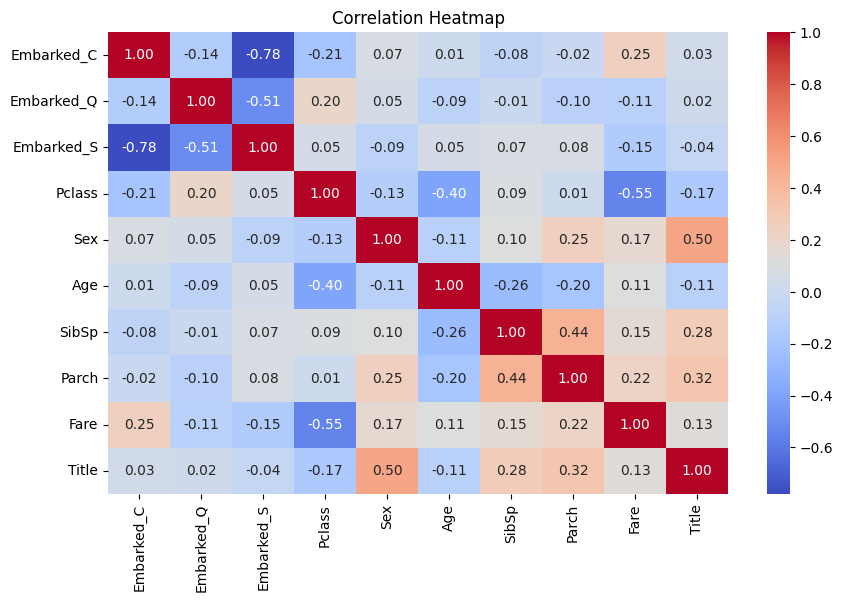

In [207]:
num_cols = ['Embarked_C', 'Embarked_Q', 'Embarked_S', 'Pclass', 'Sex', 'Age',
            'SibSp', 'Parch', 'Fare', 'Title']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')

corr = X_train.select_dtypes(include='number').corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
form sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier()


from sklearn.model_selection import 